# Patsy's Pizzeria NYC Sanitary Inspection Case Study

This Jupyter notebook demonstrates how to analyze NYC restaurant sanitary inspection data
using **pivot tables** and **conditions**, with *Patsy's Pizzeria* as the case study example.

It:
- Loads/creates inspection data
- Cleans and filters for Patsy’s
- Builds pivot tables (Grades by Year, Average Scores, Violations, etc.)
- Creates charts
- Exports a formatted Excel workbook with conditional formatting


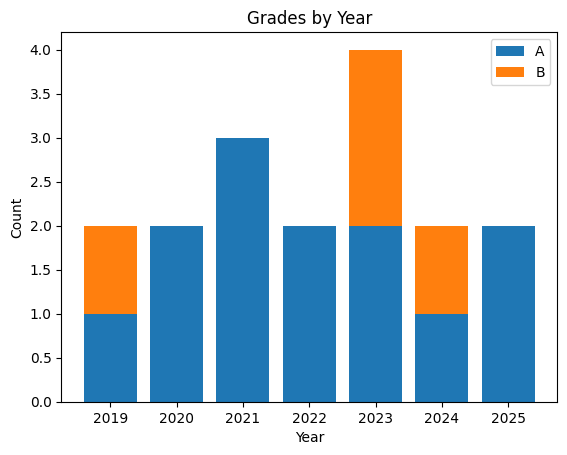

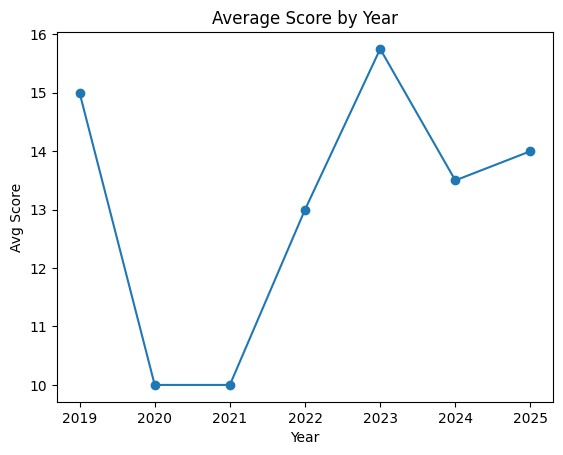

In [1]:

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# ---------- 1) Create synthetic dataset ----------
np.random.seed(7)

def make_row(camis, dba, boro, addr, zipcode, cuisine, date, action, vio_code, vio_desc, critical, score, grade):
    return dict(
        CAMIS=camis,
        DBA=dba,
        BORO=boro,
        BUILDING=addr.split(" ")[0],
        STREET=" ".join(addr.split(" ")[1:]),
        ZIPCODE=str(zipcode),
        CUISINE_DESCRIPTION=cuisine,
        INSPECTION_DATE=pd.to_datetime(date),
        ACTION=action,
        VIOLATION_CODE=vio_code,
        VIOLATION_DESCRIPTION=vio_desc,
        CRITICAL_FLAG=critical,
        SCORE=score,
        GRADE=grade,
        GRADE_DATE=pd.to_datetime(date) if pd.notna(grade) else pd.NaT,
        RECORD_DATE=pd.to_datetime(date),
    )

patsys_variants = [
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2019-03-05"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2019-10-21"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2020-07-14"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2021-05-02"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2022-09-17"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2023-02-20"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2023-11-15"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2024-05-10"),
    ("50010001", "PATSY'S PIZZERIA", "MANHATTAN", "2287 1st Ave", 10035, "Pizza", "2025-03-12"),
    ("50020002", "PATSY'S PIZZERIA - CHELSEA", "MANHATTAN", "318 W 23rd St", 10011, "Pizza", "2021-01-27"),
    ("50020002", "PATSY'S PIZZERIA - CHELSEA", "MANHATTAN", "318 W 23rd St", 10011, "Pizza", "2022-04-08"),
    ("50020002", "PATSY'S PIZZERIA - CHELSEA", "MANHATTAN", "318 W 23rd St", 10011, "Pizza", "2023-06-30"),
    ("50020002", "PATSY'S PIZZERIA - CHELSEA", "MANHATTAN", "318 W 23rd St", 10011, "Pizza", "2024-08-18"),
    ("50030003", "PATSY'S PIZZERIA OF QUEENS", "QUEENS", "30-12 36th Ave", 11106, "Pizza", "2020-02-19"),
    ("50030003", "PATSY'S PIZZERIA OF QUEENS", "QUEENS", "30-12 36th Ave", 11106, "Pizza", "2021-10-05"),
    ("50030003", "PATSY'S PIZZERIA OF QUEENS", "QUEENS", "30-12 36th Ave", 11106, "Pizza", "2023-03-21"),
    ("50030003", "PATSY'S PIZZERIA OF QUEENS", "QUEENS", "30-12 36th Ave", 11106, "Pizza", "2025-01-09"),
]

others = [
    ("70040004", "TONY'S PIZZA", "BROOKLYN", "126 Court St", 11201, "Pizza", "2023-04-15"),
    ("70050005", "MAMA MIA PIZZERIA", "BRONX", "547 E 149th St", 10455, "Pizza", "2024-10-01"),
]

vio_catalog = [
    ("02A", "Food not at required temperature", "Y"),
    ("04L", "Evidence of mice or live mice", "Y"),
    ("08A", "Personal hygiene inadequate", "Y"),
    ("10F", "Non-food contact surfaces not clean", "N"),
    ("06C", "Food contact surfaces not properly washed", "Y"),
    ("09C", "Food storage not protected", "N"),
    ("10I", "Single service items improperly stored", "N"),
    ("04N", "Filth flies", "Y"),
]

grades = ["A", "B", "A", "A", "A", "B", "A", "A", "A", "A", "A", "A", "B", "A", "A", "B", "A", "A", "A", "A"]
scores = [12, 18, 10, 9, 14, 20, 12, 11, 13, 8, 12, 14, 16, 10, 13, 17, 15, 9, 7, 12]

rows = []
for i, tpl in enumerate(patsys_variants + others):
    camis, dba, boro, addr, zp, cuis, date = tpl
    vio = vio_catalog[i % len(vio_catalog)]
    g = grades[i % len(grades)]
    s = scores[i % len(scores)]
    rows.append(
        make_row(
            camis, dba, boro, addr, zp, cuis, date,
            action="Violation Issued",
            vio_code=vio[0],
            vio_desc=vio[1],
            critical=vio[2],
            score=s,
            grade=g
        )
    )

df_raw = pd.DataFrame(rows)

# ---------- 2) Cleaning & filter ----------
df = df_raw.copy()
df["YEAR"] = df["INSPECTION_DATE"].dt.year
df_patsys = df[df["DBA"].str.contains("PATSY", case=False, na=False)].copy()

# ---------- 3) Pivot tables ----------
grades_by_year = pd.crosstab(df_patsys["YEAR"], df_patsys["GRADE"]).reset_index()
avg_score_by_year = df_patsys.groupby("YEAR", as_index=False)["SCORE"].mean().rename(columns={"SCORE": "AVG_SCORE"})
avg_score_by_location = df_patsys.groupby("DBA", as_index=False)["SCORE"].mean().rename(columns={"SCORE": "AVG_SCORE"})
severity_by_year = pd.crosstab(df_patsys["YEAR"], df_patsys["CRITICAL_FLAG"]).reset_index()
violation_counts = df_patsys.groupby(["VIOLATION_CODE","VIOLATION_DESCRIPTION"], as_index=False).size().sort_values("size",ascending=False)

# ---------- 4) Charts ----------
grades_cols = [c for c in grades_by_year.columns if c != "YEAR"]
bottom = np.zeros(len(grades_by_year))
for col in grades_cols:
    plt.bar(grades_by_year["YEAR"], grades_by_year[col], bottom=bottom, label=col)
    bottom += grades_by_year[col].values
plt.title("Grades by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

plt.plot(avg_score_by_year["YEAR"], avg_score_by_year["AVG_SCORE"], marker="o")
plt.title("Average Score by Year")
plt.xlabel("Year")
plt.ylabel("Avg Score")
plt.show()
